

# MVP-2 — Experimento 2: Encoder RNA MLP Baseline
=============================================================================
 
Notebook: mvp2_03_encoder_rna_baseline.py
Fecha: 1 de abril de 2026
Autor: JCB (asistido por Claude)
Proyecto: Inferencia del envejecimiento celular — MVP-2
 
Objetivo:
  Entrenar un MLP que mapee 2027 genes → z_rna (256-dim) → PDL_hat
  usando two-stage training (PRETRAIN → FINETUNE).
 
Decisiones incorporadas:
  1. Targets realistas: Spearman ≥ 0.811 (aspiracional), worst fold ≥ 0.60 (piso)
  2. Capa intermedia entre z_rna y PDL_hat (libertad geométrica)
  3. Batch probe condicional: AUC(sp|z_rna) vs AUC(sp|PDL+cell_line)
  4. Two-stage: PRETRAIN (345 RNA, todos treatments) → FINETUNE (86, Control+Normal)
  5. RankingLoss sobre PDL_hat (no sobre z_rna)
 
Hallazgos previos incorporados:
  - EN baseline = 0.901 (upper bound lineal)
  - 7/10 top genes acoplados bio+batch, 2 bio puros, 1 batch artifact
  - Fold 2: PDL alto + study_part distinto → worst fold esperado
  - Signal es lineal y sparse → MLP no necesita superar EN
  - Valor del encoder: z_rna fusionable, no Spearman puntual

=============================================================================


## SECCIÓN 0: CONFIGURACIÓN


In [36]:
import os
import sys
import json
import time
import copy
import warnings
from pathlib import Path
from datetime import datetime
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
 
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
 
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
 
# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
 
# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
 
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Device: mps
PyTorch: 2.2.2
Timestamp: 2026-04-01 14:51


## SECCIÓN 1: RUTAS Y PARÁMETROS


In [37]:
# --- RUTAS (AJUSTAR) ---
DATA_DIR    = Path("/Users/JCB/Documentos/Proyecto Integrador/data/")
MANIFEST_DIR = DATA_DIR / "manifests"
RESULTS_DIR = Path("/Users/JCB/Documentos/Proyecto Integrador/results_2/")
OUTPUT_DIR  = RESULTS_DIR / "mvp2_encoder_rna"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
# --- ARCHIVOS ---
MANIFEST_PRETRAIN  = "manifest_mvp2_pretrain_20260328_143235.csv"
MANIFEST_FINETUNE  = "manifest_mvp2_finetune_20260328_143235.csv"
RNA_MATRIX_FILE    = "mvp2_rna_selected_20260328_143235.csv.gz"
 
# --- HIPERPARÁMETROS ---
HP = {
    # Arquitectura
    "input_dim":      2027,
    "hidden_dim":     512,
    "z_dim":          256,     # embedding dimension (must match z_img for fusion)
    "pdl_head_dim":   64,      # intermediate layer before PDL prediction
    "dropout_input":  0.5,
    "dropout_hidden": 0.3,
 
    # Training - Stage 1 (PRETRAIN)
    "lr_pretrain":     1e-3,
    "wd_pretrain":     1e-4,
    "epochs_pretrain": 200,
    "patience_pretrain": 25,
    "batch_size_pretrain": 64,
 
    # Training - Stage 2 (FINETUNE)
    "lr_finetune":     1e-4,   # 10x lower than pretrain
    "wd_finetune":     1e-4,
    "epochs_finetune": 150,
    "patience_finetune": 20,
    "batch_size_finetune": 32, # smaller batch for smaller dataset
 
    # Loss
    "lambda_rank":    0.5,
    "rank_margin":    0.1,
 
    # General
    "seed": SEED,
    "n_folds": 3,
}
 
# --- TARGETS ---
TARGETS = {
    "spearman_aspiracional": 0.811,  # 90% de EN (0.901)
    "spearman_piso":         0.60,   # piso realista
    "worst_fold_aspiracional": 0.76, # 90% de EN worst (0.847)
    "worst_fold_piso":         0.60, # aceptable dado distribución PDL
    "delta_auc_bruto":         0.20, # batch probe bruto
    "delta_auc_condicional":   0.10, # batch probe condicional
    "overfitting_gap":         0.15, # train-val Spearman gap
}
 
print("Hiperparámetros:")
for k, v in HP.items():
    print(f"  {k}: {v}")
print(f"\nTargets:")
for k, v in TARGETS.items():
    print(f"  {k}: {v}")
 

Hiperparámetros:
  input_dim: 2027
  hidden_dim: 512
  z_dim: 256
  pdl_head_dim: 64
  dropout_input: 0.5
  dropout_hidden: 0.3
  lr_pretrain: 0.001
  wd_pretrain: 0.0001
  epochs_pretrain: 200
  patience_pretrain: 25
  batch_size_pretrain: 64
  lr_finetune: 0.0001
  wd_finetune: 0.0001
  epochs_finetune: 150
  patience_finetune: 20
  batch_size_finetune: 32
  lambda_rank: 0.5
  rank_margin: 0.1
  seed: 42
  n_folds: 3

Targets:
  spearman_aspiracional: 0.811
  spearman_piso: 0.6
  worst_fold_aspiracional: 0.76
  worst_fold_piso: 0.6
  delta_auc_bruto: 0.2
  delta_auc_condicional: 0.1
  overfitting_gap: 0.15


## SECCIÓN 2: CARGA DE DATOS

In [38]:
print("=" * 70)
print("SECCIÓN 2: Carga de datos")
print("=" * 70)
 
# Manifests
manifest_pre = pd.read_csv(MANIFEST_DIR / MANIFEST_PRETRAIN)
manifest_ft  = pd.read_csv(MANIFEST_DIR / MANIFEST_FINETUNE)
print(f"Manifest PRETRAIN: {manifest_pre.shape}")
print(f"Manifest FINETUNE: {manifest_ft.shape}")
 
# Filtrar solo muestras con RNA
pre_rna = manifest_pre[manifest_pre['has_rna'] == True].copy()
ft_rna  = manifest_ft[manifest_ft['has_rna'] == True].copy()
print(f"PRETRAIN con RNA: {len(pre_rna)}")
print(f"FINETUNE con RNA: {len(ft_rna)}")
 
# Matriz RNA
rna_raw = pd.read_csv(MANIFEST_DIR / RNA_MATRIX_FILE, compression='gzip', index_col=0)
# Si genes están como filas, transponer para tener (muestras × genes)
if rna_raw.shape[0] == HP["input_dim"]:  # genes as rows
    rna_matrix = rna_raw.T
else:
    rna_matrix = rna_raw
print(f"Matriz RNA: {rna_matrix.shape} (muestras × genes)")
 
# Verificar dimensión
assert rna_matrix.shape[1] == HP["input_dim"], \
    f"Expected {HP['input_dim']} genes, got {rna_matrix.shape[1]}"
 
# Merge PRETRAIN: manifest + expresión
rna_matrix_indexed = rna_matrix.copy()
rna_matrix_indexed.index.name = 'rna_matrix_col'
rna_matrix_indexed = rna_matrix_indexed.reset_index()
 
df_pre = pre_rna.merge(rna_matrix_indexed, on='rna_matrix_col', how='inner')
df_ft  = ft_rna.merge(rna_matrix_indexed, on='rna_matrix_col', how='inner')
 
# Limpiar NaN en variables clave
df_pre = df_pre.dropna(subset=['pdl_norm', 'fold'])
df_ft  = df_ft.dropna(subset=['pdl_norm', 'fold'])
 
print(f"\nDatos merged:")
print(f"  PRETRAIN: {len(df_pre)} muestras")
print(f"  FINETUNE: {len(df_ft)} muestras")
 
# Distribución por fold
for stage_name, df_stage in [("PRETRAIN", df_pre), ("FINETUNE", df_ft)]:
    print(f"\n  {stage_name} por fold:")
    for fold in sorted(df_stage['fold'].unique()):
        n = (df_stage['fold'] == fold).sum()
        pdl_mean = df_stage[df_stage['fold'] == fold]['pdl_norm'].mean()
        print(f"    Fold {int(fold)}: {n:>4} muestras, PDL mean={pdl_mean:.3f}")
 
# Gene names (para referencia posterior)
gene_names = [c for c in rna_matrix.columns]
assert len(gene_names) == HP["input_dim"]

SECCIÓN 2: Carga de datos
Manifest PRETRAIN: (715, 50)
Manifest FINETUNE: (161, 50)
PRETRAIN con RNA: 345
FINETUNE con RNA: 86
Matriz RNA: (345, 2027) (muestras × genes)

Datos merged:
  PRETRAIN: 339 muestras
  FINETUNE: 86 muestras

  PRETRAIN por fold:
    Fold 0:  111 muestras, PDL mean=0.451
    Fold 1:  181 muestras, PDL mean=0.523
    Fold 2:   47 muestras, PDL mean=0.520

  FINETUNE por fold:
    Fold 0:   28 muestras, PDL mean=0.486
    Fold 1:   47 muestras, PDL mean=0.566
    Fold 2:   11 muestras, PDL mean=0.541


## SECCIÓN 3: DATASET y DATALOADER


In [39]:
print("\n" + "=" * 70)
print("SECCIÓN 3: Dataset y DataLoader")
print("=" * 70)
 
class RNADataset(Dataset):
    """Dataset para RNA-seq con expresión + PDL."""
 
    def __init__(self, df, gene_names, scaler=None, fit_scaler=False):
        """
        Args:
            df: DataFrame con genes + pdl_norm + metadata
            gene_names: lista de nombres de genes (columnas)
            scaler: StandardScaler fitted (para val/test)
            fit_scaler: si True, fitea un nuevo scaler
        """
        self.pdl = torch.tensor(df['pdl_norm'].values, dtype=torch.float32)
        self.sample_ids = df['sample_id'].values if 'sample_id' in df.columns else np.arange(len(df))
        self.folds = df['fold'].values
 
        # Metadata para diagnósticos
        self.study_part = df['study_part'].values if 'study_part' in df.columns else None
        self.cell_line = df['cell_line'].values if 'cell_line' in df.columns else None
 
        # Expresión génica
        X = df[gene_names].values.astype(np.float32)
 
        if fit_scaler:
            self.scaler = StandardScaler()
            X = self.scaler.fit_transform(X)
        elif scaler is not None:
            self.scaler = scaler
            X = scaler.transform(X)
        else:
            self.scaler = None
 
        self.X = torch.tensor(X, dtype=torch.float32)
 
    def __len__(self):
        return len(self.pdl)
 
    def __getitem__(self, idx):
        return self.X[idx], self.pdl[idx]
 
 
def build_dataloaders(df, gene_names, fold_val, batch_size, stage="pretrain"):
    """
    Construye train/val DataLoaders para un fold específico.
 
    Args:
        df: DataFrame completo (PRETRAIN o FINETUNE)
        gene_names: lista de genes
        fold_val: fold a usar como validación
        batch_size: batch size
        stage: "pretrain" o "finetune" (para logging)
 
    Returns:
        train_loader, val_loader, scaler
    """
    train_mask = df['fold'] != fold_val
    val_mask   = df['fold'] == fold_val
 
    df_train = df[train_mask].reset_index(drop=True)
    df_val   = df[val_mask].reset_index(drop=True)
 
    # Fit scaler en train, aplicar en val
    ds_train = RNADataset(df_train, gene_names, fit_scaler=True)
    ds_val   = RNADataset(df_val, gene_names, scaler=ds_train.scaler)
 
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                              drop_last=len(ds_train) > batch_size)
    loader_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
 
    print(f"  [{stage}] Fold {int(fold_val)} val: "
          f"train={len(ds_train)}, val={len(ds_val)}")
 
    return loader_train, loader_val, ds_train.scaler
 
 
print("Dataset y DataLoader definidos ✓")


SECCIÓN 3: Dataset y DataLoader
Dataset y DataLoader definidos ✓


## SECCIÓN 4: MODELO

In [40]:
print("\n" + "=" * 70)
print("SECCIÓN 4: Modelo — RNA Encoder MLP")
print("=" * 70)
 
class RNAEncoder(nn.Module):
    """
    MLP encoder: RNA (2027) → z_rna (256) → PDL_hat
 
    Arquitectura:
      Input (2027) → Dropout(0.5) → Linear(512) → ReLU → Dropout(0.3)
                   → Linear(256) = z_rna
                   → Linear(64) → ReLU → Linear(1) = PDL_hat
 
    Decisión clave: Capa intermedia (64-dim) entre z_rna y PDL_hat
    da libertad geométrica al embedding para fusión, sin sacrificar
    la supervisión de PDL.
    """
 
    def __init__(self, input_dim=2027, hidden_dim=512, z_dim=256,
                 pdl_head_dim=64, dropout_input=0.5, dropout_hidden=0.3):
        super().__init__()
 
        # Encoder: input → z_rna
        self.encoder = nn.Sequential(
            nn.Dropout(dropout_input),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_hidden),
            nn.Linear(hidden_dim, z_dim),
        )
 
        # PDL head: z_rna → PDL_hat (con capa intermedia)
        self.pdl_head = nn.Sequential(
            nn.Linear(z_dim, pdl_head_dim),
            nn.ReLU(),
            nn.Linear(pdl_head_dim, 1),
        )
 
    def forward(self, x):
        """
        Returns:
            z_rna: (batch, z_dim) — embedding para fusión
            pdl_hat: (batch,) — predicción PDL escalar
        """
        z = self.encoder(x)
        pdl_hat = self.pdl_head(z).squeeze(-1)
        return z, pdl_hat
 
    def encode(self, x):
        """Solo embedding, sin head. Para extracción de z_rna."""
        with torch.no_grad():
            return self.encoder(x)
 
 
# Verificar arquitectura
model_test = RNAEncoder(**{k: HP[k] for k in
    ['input_dim', 'hidden_dim', 'z_dim', 'pdl_head_dim',
     'dropout_input', 'dropout_hidden']})
 
x_test = torch.randn(4, HP['input_dim'])
z_test, pdl_test = model_test(x_test)
print(f"Arquitectura verificada:")
print(f"  Input:   {x_test.shape}")
print(f"  z_rna:   {z_test.shape}")
print(f"  PDL_hat: {pdl_test.shape}")
 
n_params = sum(p.numel() for p in model_test.parameters())
print(f"  Parámetros: {n_params:,}")
 
print(f"\nModelo:")
print(model_test)
 
del model_test, x_test, z_test, pdl_test


SECCIÓN 4: Modelo — RNA Encoder MLP
Arquitectura verificada:
  Input:   torch.Size([4, 2027])
  z_rna:   torch.Size([4, 256])
  PDL_hat: torch.Size([4])
  Parámetros: 1,186,177

Modelo:
RNAEncoder(
  (encoder): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=2027, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
  )
  (pdl_head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## SECCIÓN 5: LOSS FUNCTIONS

In [41]:
print("\n" + "=" * 70)
print("SECCIÓN 5: Loss Functions")
print("=" * 70)
 
class RankingLoss(nn.Module):
    """
    Margin ranking loss sobre PDL_hat (NO sobre z_rna).
 
    Para pares (i, j) donde PDL_true_i > PDL_true_j:
      loss = max(0, margin - (PDL_hat_i - PDL_hat_j))
 
    Fuerza al modelo a preservar el orden de PDL en las predicciones.
    Corrección de MVP-1 A1: aplicar sobre escalar, no embedding.
    """
 
    def __init__(self, margin=0.1):
        super().__init__()
        self.margin = margin
 
    def forward(self, pdl_hat, pdl_true):
        n = len(pdl_hat)
        if n < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
 
        # Generar pares aleatorios en el mismo device para evitar errores CPU/MPS/CUDA
        n_pairs = min(n * 2, 256)  # cap para eficiencia
        idx_a = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
        idx_b = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
 
        # Filtrar pares donde PDL es distinto
        diff_true = pdl_true[idx_a] - pdl_true[idx_b]
        valid = diff_true.abs() > 0.01  # umbral mínimo
        if valid.sum() < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
 
        idx_a, idx_b = idx_a[valid], idx_b[valid]
        diff_true = diff_true[valid]
        diff_hat  = pdl_hat[idx_a] - pdl_hat[idx_b]
 
        # Margin ranking: sign(diff_true) * diff_hat > margin
        target = torch.sign(diff_true)
        loss = torch.clamp(self.margin - target * diff_hat, min=0)
 
        return loss.mean()
 
 
class CombinedLoss(nn.Module):
    """
    Loss = MSE(PDL, PDL_hat) + λ_rank * RankingLoss(PDL_hat, PDL)
    """
 
    def __init__(self, lambda_rank=0.5, rank_margin=0.1):
        super().__init__()
        self.mse = nn.MSELoss()
        self.ranking = RankingLoss(margin=rank_margin)
        self.lambda_rank = lambda_rank
 
    def forward(self, pdl_hat, pdl_true):
        l_mse = self.mse(pdl_hat, pdl_true)
        l_rank = self.ranking(pdl_hat, pdl_true)
        return l_mse + self.lambda_rank * l_rank, l_mse.item(), l_rank.item()
 
 
print("Loss functions definidas ✓")
print(f"  λ_rank = {HP['lambda_rank']}")
print(f"  margin = {HP['rank_margin']}")


SECCIÓN 5: Loss Functions
Loss functions definidas ✓
  λ_rank = 0.5
  margin = 0.1


In [42]:
# Smoke test: validar que RankingLoss funciona en el device activo
pdl_hat_test = torch.randn(32, device=DEVICE)
pdl_true_test = torch.randn(32, device=DEVICE)
loss_test = RankingLoss(margin=0.1)(pdl_hat_test, pdl_true_test)
print(f"Smoke test RankingLoss OK en {DEVICE}: loss={loss_test.item():.6f}")

Smoke test RankingLoss OK en mps: loss=0.600228


## SECCIÓN 6: TRAINING INFRASTRUCTURE


In [43]:
print("\n" + "=" * 70)
print("SECCIÓN 6: Training Infrastructure")
print("=" * 70)
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entrena un epoch. Retorna dict de métricas."""
    model.train()
    total_loss, total_mse, total_rank = 0, 0, 0
    all_pdl_hat, all_pdl_true = [], []
 
    for X, pdl in loader:
        X, pdl = X.to(device), pdl.to(device)
 
        z, pdl_hat = model(X)
        loss, mse_val, rank_val = criterion(pdl_hat, pdl)
 
        optimizer.zero_grad()
        loss.backward()
 
        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
        optimizer.step()
 
        total_loss += loss.item() * len(X)
        total_mse  += mse_val * len(X)
        total_rank += rank_val * len(X)
 
        all_pdl_hat.extend(pdl_hat.detach().cpu().numpy())
        all_pdl_true.extend(pdl.cpu().numpy())
 
    n = len(all_pdl_hat)
    rho, _ = stats.spearmanr(all_pdl_hat, all_pdl_true)
 
    return {
        'loss': total_loss / n,
        'mse': total_mse / n,
        'rank': total_rank / n,
        'spearman': rho,
    }
 
 
@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    """Evalúa un epoch. Retorna dict de métricas + predicciones."""
    model.eval()
    total_loss, total_mse, total_rank = 0, 0, 0
    all_pdl_hat, all_pdl_true, all_z = [], [], []
 
    for X, pdl in loader:
        X, pdl = X.to(device), pdl.to(device)
 
        z, pdl_hat = model(X)
        loss, mse_val, rank_val = criterion(pdl_hat, pdl)
 
        total_loss += loss.item() * len(X)
        total_mse  += mse_val * len(X)
        total_rank += rank_val * len(X)
 
        all_pdl_hat.extend(pdl_hat.cpu().numpy())
        all_pdl_true.extend(pdl.cpu().numpy())
        all_z.append(z.cpu().numpy())
 
    n = len(all_pdl_hat)
    rho, _ = stats.spearmanr(all_pdl_hat, all_pdl_true)
    mae = np.mean(np.abs(np.array(all_pdl_hat) - np.array(all_pdl_true)))
    r2 = 1 - np.sum((np.array(all_pdl_hat) - np.array(all_pdl_true))**2) / \
             np.sum((np.array(all_pdl_true) - np.mean(all_pdl_true))**2)
 
    return {
        'loss': total_loss / n,
        'mse': total_mse / n,
        'rank': total_rank / n,
        'spearman': rho,
        'mae': mae,
        'r2': r2,
        'pdl_hat': np.array(all_pdl_hat),
        'pdl_true': np.array(all_pdl_true),
        'z': np.concatenate(all_z, axis=0),
    }
 
 
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, epochs, patience, stage_name="train"):
    """
    Entrena modelo con early stopping basado en val_spearman.
 
    Returns:
        best_model_state, history dict
    """
    best_val_spearman = -1
    best_epoch = 0
    best_state = None
    no_improve = 0
 
    history = {
        'train_loss': [], 'val_loss': [],
        'train_spearman': [], 'val_spearman': [],
        'train_mse': [], 'val_mse': [],
    }
 
    print(f"\n  [{stage_name}] Training for up to {epochs} epochs "
          f"(patience={patience})...")
 
    for epoch in range(1, epochs + 1):
        t0 = time.time()
 
        train_metrics = train_one_epoch(model, train_loader, criterion,
                                         optimizer, device)
        val_metrics   = eval_one_epoch(model, val_loader, criterion, device)
 
        if scheduler is not None:
            scheduler.step(val_metrics['spearman'])
 
        # History
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_spearman'].append(train_metrics['spearman'])
        history['val_spearman'].append(val_metrics['spearman'])
        history['train_mse'].append(train_metrics['mse'])
        history['val_mse'].append(val_metrics['mse'])
 
        # Early stopping
        if val_metrics['spearman'] > best_val_spearman:
            best_val_spearman = val_metrics['spearman']
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
 
        # Print cada 10 epochs o al final
        if epoch % 10 == 0 or epoch == 1 or no_improve == 0:
            dt = time.time() - t0
            gap = train_metrics['spearman'] - val_metrics['spearman']
            print(f"    Ep {epoch:>3d} | "
                  f"Train ρ={train_metrics['spearman']:.3f} "
                  f"Val ρ={val_metrics['spearman']:.3f} "
                  f"Gap={gap:+.3f} | "
                  f"MSE={val_metrics['mse']:.4f} | "
                  f"{dt:.1f}s"
                  f"{' ★' if no_improve == 0 else ''}")
 
        if no_improve >= patience:
            print(f"    Early stopping at epoch {epoch} "
                  f"(best={best_epoch}, ρ={best_val_spearman:.4f})")
            break
 
    # Restaurar mejor modelo
    model.load_state_dict(best_state)
 
    print(f"  [{stage_name}] Best epoch: {best_epoch}, "
          f"Val Spearman: {best_val_spearman:.4f}")
 
    history['best_epoch'] = best_epoch
    history['best_val_spearman'] = best_val_spearman
 
    return best_state, history
 
 
print("Training infrastructure definida ✓")


SECCIÓN 6: Training Infrastructure
Training infrastructure definida ✓


## SECCIÓN 7: TWO-STAGE TRAINING (PRETRAIN → FINETUNE)

In [44]:
print("\n" + "=" * 70)
print("SECCIÓN 7: Two-Stage Training")
print("=" * 70)
print("""
Decisión: Two-stage training.
  Stage 1 (PRETRAIN): 345 muestras RNA, todos treatments.
    - Aprende representación general gen→aging.
    - lr=1e-3, patience=25, batch=64.
  Stage 2 (FINETUNE): 86 muestras RNA, solo Control+Normal.
    - Calibra para señal limpia de aging sin drug response.
    - lr=1e-4 (10x menor), patience=20, batch=32.
 
Justificación:
  - En MVP-1, two-stage estabilizó Fold 2 (0.399→0.589).
  - Con 47 val muestras en Fold 2, más datos de train ayudan.
  - PRETRAIN incluye treatments que aún tienen señal de PDL.
  - FINETUNE recalibra sin drug confounding.
""")
 
folds = sorted(df_pre['fold'].dropna().unique())
print(f"Folds: {folds}")
 
# Almacenar resultados por fold
all_results = {}
 
for fold_val in folds:
    fold_int = int(fold_val)
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_int} (validación)")
    print(f"{'='*60}")
 
    # ---------------------------------------------------------------
    # STAGE 1: PRETRAIN (todos treatments)
    # ---------------------------------------------------------------
    print(f"\n  --- Stage 1: PRETRAIN ---")
 
    train_loader_pre, val_loader_pre, scaler_pre = build_dataloaders(
        df_pre, gene_names, fold_val,
        batch_size=HP['batch_size_pretrain'],
        stage="PRETRAIN"
    )
 
    model = RNAEncoder(
        input_dim=HP['input_dim'],
        hidden_dim=HP['hidden_dim'],
        z_dim=HP['z_dim'],
        pdl_head_dim=HP['pdl_head_dim'],
        dropout_input=HP['dropout_input'],
        dropout_hidden=HP['dropout_hidden'],
    ).to(DEVICE)
 
    criterion = CombinedLoss(
        lambda_rank=HP['lambda_rank'],
        rank_margin=HP['rank_margin'],
    )
 
    optimizer_pre = optim.AdamW(
        model.parameters(),
        lr=HP['lr_pretrain'],
        weight_decay=HP['wd_pretrain'],
    )
    scheduler_pre = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_pre, mode='max', factor=0.5, patience=10, verbose=False
    )
 
    state_pre, history_pre = train_model(
        model, train_loader_pre, val_loader_pre,
        criterion, optimizer_pre, scheduler_pre, DEVICE,
        epochs=HP['epochs_pretrain'],
        patience=HP['patience_pretrain'],
        stage_name=f"PRETRAIN F{fold_int}"
    )
 
    # Evaluar Stage 1
    model.load_state_dict(state_pre)
    pre_eval = eval_one_epoch(model, val_loader_pre, criterion, DEVICE)
    print(f"  Stage 1 final: ρ={pre_eval['spearman']:.4f}, "
          f"MAE={pre_eval['mae']:.4f}, R²={pre_eval['r2']:.4f}")
 
    # ---------------------------------------------------------------
    # STAGE 2: FINETUNE (Control + Normal only)
    # ---------------------------------------------------------------
    print(f"\n  --- Stage 2: FINETUNE ---")
 
    # Verificar que hay suficientes muestras en este fold
    ft_val_count = (df_ft['fold'] == fold_val).sum()
    ft_train_count = (df_ft['fold'] != fold_val).sum()
    print(f"  FINETUNE: train={ft_train_count}, val={ft_val_count}")
 
    if ft_train_count < 10 or ft_val_count < 5:
        print(f"  ⚠️ Insuficientes muestras FINETUNE para fold {fold_int}.")
        print(f"     Usando resultado de PRETRAIN directamente.")
        best_state = state_pre
        history_ft = None
        # Evaluar en val FINETUNE con modelo de PRETRAIN
        # Necesitamos crear loaders de FINETUNE con el scaler de PRETRAIN
        ds_ft_val = RNADataset(
            df_ft[df_ft['fold'] == fold_val].reset_index(drop=True),
            gene_names, scaler=scaler_pre
        )
        loader_ft_val = DataLoader(ds_ft_val, batch_size=32, shuffle=False)
        ft_eval = eval_one_epoch(model, loader_ft_val, criterion, DEVICE)
    else:
        # Re-build dataloaders para FINETUNE
        # IMPORTANTE: usar scaler de PRETRAIN para consistencia
        ds_ft_train = RNADataset(
            df_ft[df_ft['fold'] != fold_val].reset_index(drop=True),
            gene_names, scaler=scaler_pre  # scaler de pretrain
        )
        ds_ft_val = RNADataset(
            df_ft[df_ft['fold'] == fold_val].reset_index(drop=True),
            gene_names, scaler=scaler_pre
        )
        loader_ft_train = DataLoader(
            ds_ft_train,
            batch_size=min(HP['batch_size_finetune'], len(ds_ft_train)),
            shuffle=True
        )
        loader_ft_val = DataLoader(ds_ft_val, batch_size=32, shuffle=False)
 
        # Lower learning rate for fine-tuning
        optimizer_ft = optim.AdamW(
            model.parameters(),
            lr=HP['lr_finetune'],
            weight_decay=HP['wd_finetune'],
        )
        scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_ft, mode='max', factor=0.5, patience=8, verbose=False
        )
 
        best_state, history_ft = train_model(
            model, loader_ft_train, loader_ft_val,
            criterion, optimizer_ft, scheduler_ft, DEVICE,
            epochs=HP['epochs_finetune'],
            patience=HP['patience_finetune'],
            stage_name=f"FINETUNE F{fold_int}"
        )
 
        model.load_state_dict(best_state)
        ft_eval = eval_one_epoch(model, loader_ft_val, criterion, DEVICE)
 
    print(f"\n  Stage 2 final: ρ={ft_eval['spearman']:.4f}, "
          f"MAE={ft_eval['mae']:.4f}, R²={ft_eval['r2']:.4f}")
 
    # Overfitting gap (train spearman del último history)
    if history_ft is not None:
        best_ep = history_ft['best_epoch'] - 1  # 0-indexed
        if best_ep < len(history_ft['train_spearman']):
            train_rho = history_ft['train_spearman'][best_ep]
        else:
            train_rho = history_ft['train_spearman'][-1]
    else:
        best_ep = history_pre['best_epoch'] - 1
        train_rho = history_pre['train_spearman'][min(best_ep, len(history_pre['train_spearman'])-1)]
 
    gap = train_rho - ft_eval['spearman']
    print(f"  Overfitting gap: {gap:+.3f} (train={train_rho:.3f}, val={ft_eval['spearman']:.3f})")
 
    # ---------------------------------------------------------------
    # GUARDAR RESULTADOS DEL FOLD
    # ---------------------------------------------------------------
    all_results[fold_int] = {
        'pre_spearman': pre_eval['spearman'],
        'ft_spearman':  ft_eval['spearman'],
        'ft_mae':       ft_eval['mae'],
        'ft_r2':        ft_eval['r2'],
        'overfitting_gap': gap,
        'train_spearman':  train_rho,
        'z_val':        ft_eval['z'],
        'pdl_hat_val':  ft_eval['pdl_hat'],
        'pdl_true_val': ft_eval['pdl_true'],
        'history_pre':  history_pre,
        'history_ft':   history_ft,
        'model_state':  best_state,
        'scaler':       scaler_pre,
    }
 
    # Guardar modelo del fold
    model_path = OUTPUT_DIR / f"fold{fold_int}_model.pt"
    torch.save({
        'model_state_dict': best_state,
        'hp': HP,
        'fold': fold_int,
        'metrics': {
            'pre_spearman': pre_eval['spearman'],
            'ft_spearman':  ft_eval['spearman'],
            'ft_mae':       ft_eval['mae'],
            'ft_r2':        ft_eval['r2'],
        },
    }, model_path)
    print(f"  Modelo guardado: {model_path.name}")


SECCIÓN 7: Two-Stage Training

Decisión: Two-stage training.
  Stage 1 (PRETRAIN): 345 muestras RNA, todos treatments.
    - Aprende representación general gen→aging.
    - lr=1e-3, patience=25, batch=64.
  Stage 2 (FINETUNE): 86 muestras RNA, solo Control+Normal.
    - Calibra para señal limpia de aging sin drug response.
    - lr=1e-4 (10x menor), patience=20, batch=32.

Justificación:
  - En MVP-1, two-stage estabilizó Fold 2 (0.399→0.589).
  - Con 47 val muestras en Fold 2, más datos de train ayudan.
  - PRETRAIN incluye treatments que aún tienen señal de PDL.
  - FINETUNE recalibra sin drug confounding.

Folds: [0.0, 1.0, 2.0]

  FOLD 0 (validación)

  --- Stage 1: PRETRAIN ---
  [PRETRAIN] Fold 0 val: train=228, val=111

  [PRETRAIN F0] Training for up to 200 epochs (patience=25)...
    Ep   1 | Train ρ=0.319 Val ρ=0.897 Gap=-0.579 | MSE=0.1278 | 0.1s ★
    Ep   3 | Train ρ=0.719 Val ρ=0.907 Gap=-0.188 | MSE=0.0110 | 0.0s ★
    Ep   7 | Train ρ=0.890 Val ρ=0.911 Gap=-0.021 | MSE

## SECCIÓN 8: RESUMEN DE MÉTRICAS

In [45]:
print("\n" + "=" * 70)
print("SECCIÓN 8: Resumen de Métricas")
print("=" * 70)
 
# Tabla resumen
print("\n--- Métricas por fold ---\n")
print(f"{'Fold':<6} {'PRE ρ':>8} {'FT ρ':>8} {'MAE':>8} {'R²':>8} {'Gap':>8}")
print("-" * 48)
 
spearmans_ft = []
for fold_int in sorted(all_results.keys()):
    r = all_results[fold_int]
    print(f"  {fold_int:<4} {r['pre_spearman']:>8.4f} {r['ft_spearman']:>8.4f} "
          f"{r['ft_mae']:>8.4f} {r['ft_r2']:>8.4f} {r['overfitting_gap']:>+8.3f}")
    spearmans_ft.append(r['ft_spearman'])
 
mean_rho = np.mean(spearmans_ft)
std_rho  = np.std(spearmans_ft)
worst_rho = np.min(spearmans_ft)
worst_fold = [f for f in all_results if all_results[f]['ft_spearman'] == worst_rho][0]
 
print(f"\n  Promedio: {mean_rho:.4f} ± {std_rho:.4f}")
print(f"  Worst:    {worst_rho:.4f} (Fold {worst_fold})")
 
# Comparación con targets
print(f"\n--- Comparación con targets ---\n")
checks = [
    ("Spearman promedio ≥ aspiracional", mean_rho, TARGETS['spearman_aspiracional']),
    ("Spearman promedio ≥ piso", mean_rho, TARGETS['spearman_piso']),
    ("Worst fold ≥ aspiracional", worst_rho, TARGETS['worst_fold_aspiracional']),
    ("Worst fold ≥ piso", worst_rho, TARGETS['worst_fold_piso']),
]
for name, actual, target in checks:
    status = "✅ PASA" if actual >= target else "❌ FALLA"
    print(f"  {status} {name}: {actual:.4f} vs {target:.4f}")
 
# Comparación con baseline EN
print(f"\n--- vs Elastic Net baseline ---\n")
en_mean = 0.901
en_worst = 0.847
pct_mean = (mean_rho / en_mean) * 100
pct_worst = (worst_rho / en_worst) * 100 if en_worst > 0 else 0
print(f"  Spearman promedio: {mean_rho:.4f} / {en_mean:.4f} = {pct_mean:.1f}% del EN")
print(f"  Worst fold:        {worst_rho:.4f} / {en_worst:.4f} = {pct_worst:.1f}% del EN")
 
max_gap = max(r['overfitting_gap'] for r in all_results.values())
print(f"\n  Max overfitting gap: {max_gap:+.3f} (target < {TARGETS['overfitting_gap']:.2f})")


SECCIÓN 8: Resumen de Métricas

--- Métricas por fold ---

Fold      PRE ρ     FT ρ      MAE       R²      Gap
------------------------------------------------
  0      0.9400   0.9721   0.1183   0.7945   -0.009
  1      0.9298   0.9495   0.1439   0.6529   +0.026
  2      0.9159   0.9091   0.2857  -0.7583   +0.039

  Promedio: 0.9435 ± 0.0261
  Worst:    0.9091 (Fold 2)

--- Comparación con targets ---

  ✅ PASA Spearman promedio ≥ aspiracional: 0.9435 vs 0.8110
  ✅ PASA Spearman promedio ≥ piso: 0.9435 vs 0.6000
  ✅ PASA Worst fold ≥ aspiracional: 0.9091 vs 0.7600
  ✅ PASA Worst fold ≥ piso: 0.9091 vs 0.6000

--- vs Elastic Net baseline ---

  Spearman promedio: 0.9435 / 0.9010 = 104.7% del EN
  Worst fold:        0.9091 / 0.8470 = 107.3% del EN

  Max overfitting gap: +0.039 (target < 0.15)


## SECCIÓN 9: BATCH PROBE (BRUTO + CONDICIONAL)

In [47]:
print("\n" + "=" * 70)
print("SECCIÓN 9: Batch Probe — study_part")
print("=" * 70)
print("""
Operacionalización:
  1. BRUTO: AUC de clasificar study_part desde z_rna
  2. BASELINE: AUC de clasificar study_part desde PDL + cell_line
  3. CONDICIONAL: ΔAUC = AUC(z_rna) - AUC(PDL+cell_line)
 
Si ΔAUC condicional < 0.10 → z_rna no añade información de batch
más allá de lo que PDL + cell_line ya explican. Señal limpia.
""")
 
batch_results = {}
 
for fold_int in sorted(all_results.keys()):
    r = all_results[fold_int]
    z_val = r['z_val']
 
    # Obtener metadata del val set
    val_mask = df_ft['fold'] == fold_int if len(df_ft[df_ft['fold'] == fold_int]) >= 5 \
               else df_pre['fold'] == fold_int
    df_source = df_ft if len(df_ft[df_ft['fold'] == fold_int]) >= 5 else df_pre
    df_val = df_source[df_source['fold'] == fold_int].reset_index(drop=True)
 
    # Verificar que tenemos study_part
    if 'study_part' not in df_val.columns or df_val['study_part'].nunique() < 2:
        print(f"  Fold {fold_int}: study_part no disponible o constante. Saltando.")
        batch_results[fold_int] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue
 
    # Alinear longitudes (puede haber discrepancia por NaN)
    n_z = len(z_val)
    n_df = len(df_val)
    n_use = min(n_z, n_df)
 
    sp = df_val['study_part'].values[:n_use]
    pdl_val_arr = df_val['pdl_norm'].values[:n_use]
    cl_val = df_val['cell_line'].values[:n_use]
    z_use = z_val[:n_use]
 
    # Eliminar NaN en study_part
    valid = ~pd.isna(sp)
    sp, pdl_val_arr, cl_val, z_use = sp[valid], pdl_val_arr[valid], cl_val[valid], z_use[valid]
 
    if len(np.unique(sp)) < 2:
        print(f"  Fold {fold_int}: study_part constante tras filtro. Saltando.")
        batch_results[fold_int] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue
 
    # Encode cell_line como dummy
    le = LabelEncoder()
    cl_encoded = le.fit_transform(cl_val).reshape(-1, 1)
 
    # --- AUC desde z_rna ---
    try:
        scaler_z = StandardScaler()
        z_scaled = scaler_z.fit_transform(z_use)
        clf_z = LogisticRegression(max_iter=500, C=1.0)
        clf_z.fit(z_scaled, sp)
        if len(np.unique(sp)) == 2:
            auc_z = roc_auc_score(sp, clf_z.predict_proba(z_scaled)[:, 1])
        else:
            auc_z = roc_auc_score(
                sp, clf_z.predict_proba(z_scaled), multi_class='ovr', average='macro'
            )
    except Exception as e:
        print(f"  Fold {fold_int}: Error AUC z_rna: {e}")
        auc_z = 0.5
 
    # --- AUC baseline: PDL + cell_line ---
    try:
        X_base = np.column_stack([pdl_val_arr.reshape(-1, 1), cl_encoded])
        scaler_b = StandardScaler()
        X_base_scaled = scaler_b.fit_transform(X_base)
        clf_base = LogisticRegression(max_iter=500, C=1.0)
        clf_base.fit(X_base_scaled, sp)
        if len(np.unique(sp)) == 2:
            auc_base = roc_auc_score(sp, clf_base.predict_proba(X_base_scaled)[:, 1])
        else:
            auc_base = roc_auc_score(
                sp, clf_base.predict_proba(X_base_scaled), multi_class='ovr', average='macro'
            )
    except Exception as e:
        print(f"  Fold {fold_int}: Error AUC baseline: {e}")
        auc_base = 0.5
 
    delta_auc = auc_z - auc_base
 
    batch_results[fold_int] = {
        'auc_z': auc_z,
        'auc_baseline': auc_base,
        'delta': delta_auc,
    }
 
    print(f"  Fold {fold_int}: AUC(z_rna)={auc_z:.3f}, "
          f"AUC(PDL+cl)={auc_base:.3f}, ΔAUC={delta_auc:+.3f}")
 
# Resumen batch probe
print(f"\n--- Resumen batch probe ---")
deltas = [v['delta'] for v in batch_results.values() if v['delta'] is not None]
aucs_z = [v['auc_z'] for v in batch_results.values() if v['auc_z'] is not None]
 
if deltas:
    mean_delta = np.mean(deltas)
    max_delta  = np.max(deltas)
    mean_auc_z = np.mean(aucs_z)
 
    print(f"  ΔAUC promedio:    {mean_delta:+.3f}")
    print(f"  ΔAUC máximo:      {max_delta:+.3f}")
    print(f"  AUC(z_rna) prom:  {mean_auc_z:.3f}")
 
    if max_delta < TARGETS['delta_auc_condicional']:
        print(f"  ✅ ΔAUC condicional < {TARGETS['delta_auc_condicional']} → Señal limpia")
    elif max_delta < TARGETS['delta_auc_bruto']:
        print(f"  ⚠️ ΔAUC condicional entre {TARGETS['delta_auc_condicional']} y "
              f"{TARGETS['delta_auc_bruto']} → Contaminación moderada")
    else:
        print(f"  🔴 ΔAUC condicional > {TARGETS['delta_auc_bruto']} → Contaminación alta")


SECCIÓN 9: Batch Probe — study_part

Operacionalización:
  1. BRUTO: AUC de clasificar study_part desde z_rna
  2. BASELINE: AUC de clasificar study_part desde PDL + cell_line
  3. CONDICIONAL: ΔAUC = AUC(z_rna) - AUC(PDL+cell_line)

Si ΔAUC condicional < 0.10 → z_rna no añade información de batch
más allá de lo que PDL + cell_line ya explican. Señal limpia.

  Fold 0: AUC(z_rna)=1.000, AUC(PDL+cl)=0.632, ΔAUC=+0.368
  Fold 1: AUC(z_rna)=1.000, AUC(PDL+cl)=0.769, ΔAUC=+0.231
  Fold 2: study_part no disponible o constante. Saltando.

--- Resumen batch probe ---
  ΔAUC promedio:    +0.300
  ΔAUC máximo:      +0.368
  AUC(z_rna) prom:  1.000
  🔴 ΔAUC condicional > 0.2 → Contaminación alta


## SECCIÓN 10: PLOTS DIAGNÓSTICOS


SECCIÓN 10: Plots diagnósticos


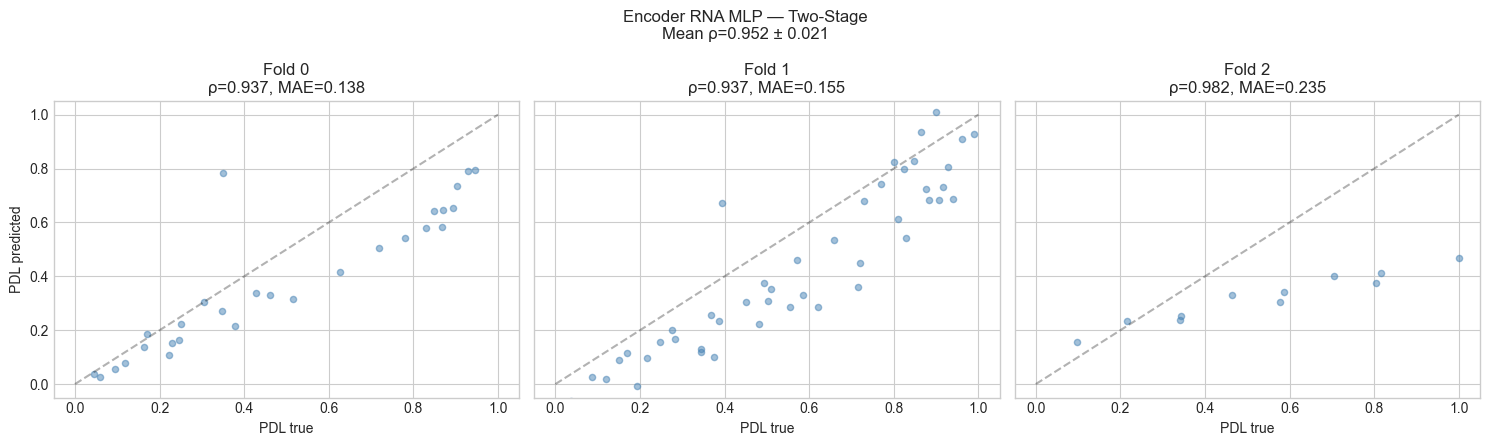

  ✓ scatter_pdl_pred_by_fold.png


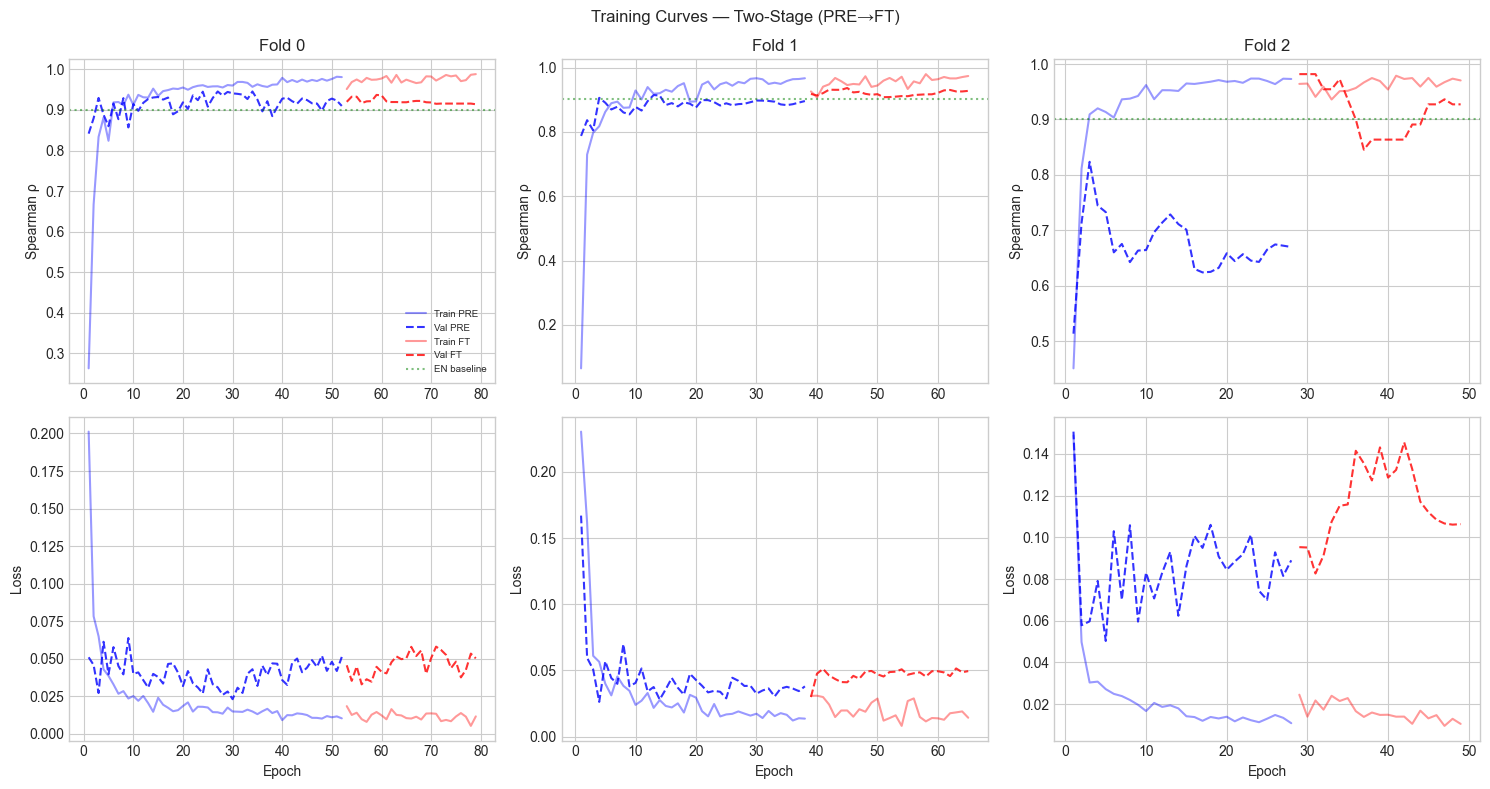

  ✓ training_curves.png


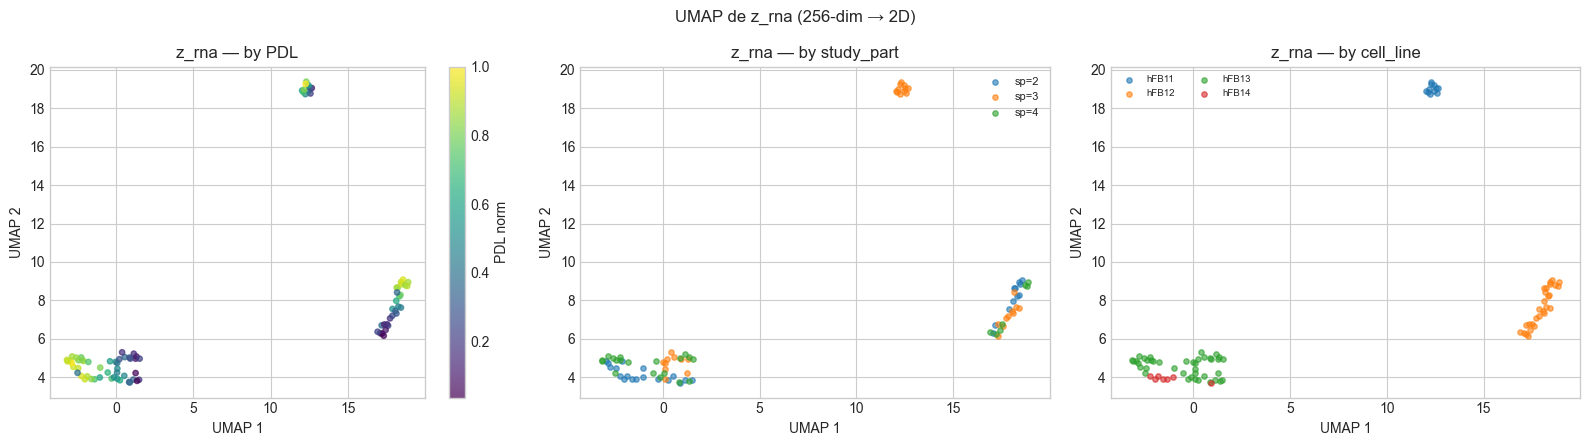

  ✓ umap_z_rna.png


In [25]:
print("\n" + "=" * 70)
print("SECCIÓN 10: Plots diagnósticos")
print("=" * 70)
 
plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(exist_ok=True)
 
# --- 10a: Scatter PDL_hat vs PDL_true por fold ---
fig, axes = plt.subplots(1, len(folds), figsize=(5*len(folds), 4.5),
                          sharey=True, squeeze=False)
 
for i, fold_int in enumerate(sorted(all_results.keys())):
    ax = axes[0][i]
    r = all_results[fold_int]
    ax.scatter(r['pdl_true_val'], r['pdl_hat_val'], alpha=0.5, s=20, c='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='ideal')
    ax.set_xlabel('PDL true')
    if i == 0:
        ax.set_ylabel('PDL predicted')
    ax.set_title(f"Fold {fold_int}\nρ={r['ft_spearman']:.3f}, "
                 f"MAE={r['ft_mae']:.3f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
 
fig.suptitle(f"Encoder RNA MLP — Two-Stage\n"
             f"Mean ρ={mean_rho:.3f} ± {std_rho:.3f}", fontsize=12)
fig.tight_layout()
fig.savefig(plots_dir / "scatter_pdl_pred_by_fold.png", dpi=150)
plt.show()
print(f"  ✓ scatter_pdl_pred_by_fold.png")
 
# --- 10b: Training curves ---
fig, axes = plt.subplots(2, len(folds), figsize=(5*len(folds), 8), squeeze=False)
 
for i, fold_int in enumerate(sorted(all_results.keys())):
    r = all_results[fold_int]
 
    # Spearman curves
    ax = axes[0][i]
    # Stage 1
    h_pre = r['history_pre']
    ep_pre = range(1, len(h_pre['train_spearman'])+1)
    ax.plot(ep_pre, h_pre['train_spearman'], 'b-', alpha=0.4, label='Train PRE')
    ax.plot(ep_pre, h_pre['val_spearman'], 'b--', alpha=0.8, label='Val PRE')
    # Stage 2
    h_ft = r['history_ft']
    if h_ft is not None:
        offset = len(h_pre['train_spearman'])
        ep_ft = range(offset+1, offset+len(h_ft['train_spearman'])+1)
        ax.plot(ep_ft, h_ft['train_spearman'], 'r-', alpha=0.4, label='Train FT')
        ax.plot(ep_ft, h_ft['val_spearman'], 'r--', alpha=0.8, label='Val FT')
    ax.axhline(y=0.901, color='green', linestyle=':', alpha=0.5, label='EN baseline')
    ax.set_ylabel('Spearman ρ')
    ax.set_title(f'Fold {fold_int}')
    if i == 0:
        ax.legend(fontsize=7)
 
    # Loss curves
    ax2 = axes[1][i]
    ax2.plot(ep_pre, h_pre['train_loss'], 'b-', alpha=0.4, label='Train PRE')
    ax2.plot(ep_pre, h_pre['val_loss'], 'b--', alpha=0.8, label='Val PRE')
    if h_ft is not None:
        ax2.plot(ep_ft, h_ft['train_loss'], 'r-', alpha=0.4, label='Train FT')
        ax2.plot(ep_ft, h_ft['val_loss'], 'r--', alpha=0.8, label='Val FT')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
 
fig.suptitle("Training Curves — Two-Stage (PRE→FT)", fontsize=12)
fig.tight_layout()
fig.savefig(plots_dir / "training_curves.png", dpi=150)
plt.show()
print(f"  ✓ training_curves.png")
 
# --- 10c: UMAP de z_rna ---
try:
    from umap import UMAP
 
    # Concatenar z de todos los folds
    all_z_list, all_pdl_list, all_fold_list = [], [], []
    for fold_int in sorted(all_results.keys()):
        r = all_results[fold_int]
        all_z_list.append(r['z_val'])
        all_pdl_list.extend(r['pdl_true_val'])
        all_fold_list.extend([fold_int] * len(r['pdl_true_val']))
 
    z_all = np.concatenate(all_z_list, axis=0)
    pdl_all = np.array(all_pdl_list)
    fold_all = np.array(all_fold_list)
 
    # Obtener study_part y cell_line para colorear
    sp_all, cl_all = [], []
    for fold_int in sorted(all_results.keys()):
        df_source = df_ft if len(df_ft[df_ft['fold'] == fold_int]) >= 5 else df_pre
        df_val_f = df_source[df_source['fold'] == fold_int].reset_index(drop=True)
        n_z = len(all_results[fold_int]['z_val'])
        sp_all.extend(df_val_f['study_part'].values[:n_z])
        cl_all.extend(df_val_f['cell_line'].values[:n_z])
    sp_all = np.array(sp_all)
    cl_all = np.array(cl_all)
 
    # Fit UMAP
    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
    z_2d = reducer.fit_transform(z_all)
 
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
 
    # By PDL
    sc = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=pdl_all, cmap='viridis',
                          s=15, alpha=0.7)
    plt.colorbar(sc, ax=axes[0], label='PDL norm')
    axes[0].set_title('z_rna — by PDL')
 
    # By study_part
    for sp_val in np.unique(sp_all[~pd.isna(sp_all)]):
        mask = sp_all == sp_val
        axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], s=15, alpha=0.6,
                        label=f'sp={int(sp_val)}')
    axes[1].legend(fontsize=8)
    axes[1].set_title('z_rna — by study_part')
 
    # By cell_line
    for cl_val in np.unique(cl_all):
        mask = cl_all == cl_val
        axes[2].scatter(z_2d[mask, 0], z_2d[mask, 1], s=15, alpha=0.6,
                        label=cl_val)
    axes[2].legend(fontsize=7, ncol=2)
    axes[2].set_title('z_rna — by cell_line')
 
    for ax in axes:
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
 
    fig.suptitle("UMAP de z_rna (256-dim → 2D)", fontsize=12)
    fig.tight_layout()
    fig.savefig(plots_dir / "umap_z_rna.png", dpi=150)
    plt.show()
    print(f"  ✓ umap_z_rna.png")
 
except ImportError:
    print("  ⚠️ umap-learn no instalado. Saltando UMAP.")
    print("     pip install umap-learn")

## SECCIÓN 11: CORRELACIÓN PARCIAL CON BIOMARCADORES


In [26]:
print("\n" + "=" * 70)
print("SECCIÓN 11: Correlación parcial z_rna vs biomarcadores")
print("=" * 70)
print("""
Verifica si z_rna captura señal biológica más allá de PDL.
Biomarcadores: telomere_length, mtdna_cn, clock_horvath1, clock_phenoage
Método: correlación parcial ρ(z_rna_mean, biomarker | PDL)
""")
 
biomarkers = ['telomere_length', 'mtdna_cn', 'clock_horvath1',
              'clock_phenoage', 'clock_grimage']
 
# Construir tabla: z_rna (promedio de dims), PDL, biomarcadores
# Usando FINETUNE set (o PRETRAIN si FINETUNE es muy pequeño)
bio_results = []
 
for bm in biomarkers:
    # Buscar biomarcador en los dataframes
    source_df = df_ft if bm in df_ft.columns else df_pre
    if bm not in source_df.columns:
        print(f"  {bm}: columna no encontrada. Saltando.")
        continue
 
    # Concatenar z_val con metadata
    z_means, pdl_vals, bm_vals = [], [], []
    for fold_int in sorted(all_results.keys()):
        r = all_results[fold_int]
        df_val_f = source_df[source_df['fold'] == fold_int].reset_index(drop=True)
        n_z = len(r['z_val'])
        n_df = len(df_val_f)
        n_use = min(n_z, n_df)
 
        z_mean_fold = r['z_val'][:n_use].mean(axis=1)  # promedio de 256 dims
        pdl_fold    = df_val_f['pdl_norm'].values[:n_use]
        bm_fold     = df_val_f[bm].values[:n_use]
 
        # Filtrar NaN
        valid = ~np.isnan(bm_fold) & ~np.isnan(pdl_fold)
        z_means.extend(z_mean_fold[valid])
        pdl_vals.extend(pdl_fold[valid])
        bm_vals.extend(bm_fold[valid])
 
    z_means = np.array(z_means)
    pdl_vals = np.array(pdl_vals)
    bm_vals = np.array(bm_vals)
 
    if len(z_means) < 10:
        print(f"  {bm}: insuficientes muestras ({len(z_means)}). Saltando.")
        continue
 
    # Correlación bruta
    rho_brut, p_brut = stats.spearmanr(z_means, bm_vals)
 
    # Correlación parcial (residualizar ambos respecto a PDL)
    slope_z, int_z, _, _, _ = stats.linregress(pdl_vals, z_means)
    slope_b, int_b, _, _, _ = stats.linregress(pdl_vals, bm_vals)
    resid_z = z_means - (slope_z * pdl_vals + int_z)
    resid_b = bm_vals - (slope_b * pdl_vals + int_b)
    rho_parcial, p_parcial = stats.spearmanr(resid_z, resid_b)
 
    bio_results.append({
        'biomarker': bm,
        'n_samples': len(z_means),
        'rho_brut': rho_brut,
        'p_brut': p_brut,
        'rho_parcial': rho_parcial,
        'p_parcial': p_parcial,
    })
 
    sig_brut    = "***" if p_brut < 0.001 else "**" if p_brut < 0.01 else "*" if p_brut < 0.05 else "ns"
    sig_parcial = "***" if p_parcial < 0.001 else "**" if p_parcial < 0.01 else "*" if p_parcial < 0.05 else "ns"
 
    print(f"  {bm:<20} n={len(z_means):>3} | "
          f"ρ_brut={rho_brut:+.3f}{sig_brut:>4} | "
          f"ρ_parcial={rho_parcial:+.3f}{sig_parcial:>4}")
 
if bio_results:
    df_bio = pd.DataFrame(bio_results)
    df_bio.to_csv(OUTPUT_DIR / "correlacion_biomarcadores.csv", index=False)
    print(f"\n  ✓ correlacion_biomarcadores.csv guardado")


SECCIÓN 11: Correlación parcial z_rna vs biomarcadores

Verifica si z_rna captura señal biológica más allá de PDL.
Biomarcadores: telomere_length, mtdna_cn, clock_horvath1, clock_phenoage
Método: correlación parcial ρ(z_rna_mean, biomarker | PDL)

  telomere_length      n= 43 | ρ_brut=-0.190  ns | ρ_parcial=-0.084  ns
  mtdna_cn             n= 43 | ρ_brut=+0.046  ns | ρ_parcial=+0.133  ns
  clock_horvath1       n= 43 | ρ_brut=-0.117  ns | ρ_parcial=-0.480  **
  clock_phenoage       n= 43 | ρ_brut=+0.092  ns | ρ_parcial=-0.151  ns
  clock_grimage        n= 43 | ρ_brut=-0.527 *** | ρ_parcial=-0.614 ***

  ✓ correlacion_biomarcadores.csv guardado


## SECCIÓN 12: GUARDAR EMBEDDINGS Y MÉTRICAS FINALES

In [27]:
print("\n" + "=" * 70)
print("SECCIÓN 12: Guardar embeddings y métricas finales")
print("=" * 70)
 
# --- Embeddings CSV ---
embeddings_rows = []
for fold_int in sorted(all_results.keys()):
    r = all_results[fold_int]
    df_source = df_ft if len(df_ft[df_ft['fold'] == fold_int]) >= 5 else df_pre
    df_val_f = df_source[df_source['fold'] == fold_int].reset_index(drop=True)
    n_use = min(len(r['z_val']), len(df_val_f))
 
    for j in range(n_use):
        row = {
            'sample_id': df_val_f.iloc[j].get('sample_id', f'sample_{j}'),
            'fold': fold_int,
            'pdl_true': r['pdl_true_val'][j],
            'pdl_hat':  r['pdl_hat_val'][j],
        }
        # z dimensions
        for d in range(r['z_val'].shape[1]):
            row[f'z_{d}'] = r['z_val'][j, d]
        embeddings_rows.append(row)
 
df_embeddings = pd.DataFrame(embeddings_rows)
emb_path = OUTPUT_DIR / "embeddings_z_rna.csv"
df_embeddings.to_csv(emb_path, index=False)
print(f"  ✓ Embeddings: {emb_path.name} ({df_embeddings.shape})")
 
# --- Métricas JSON ---
metrics_summary = {
    "experiment": "MVP2_Experiment2_RNA_MLP_TwoStage",
    "date": datetime.now().isoformat(),
    "hyperparameters": HP,
    "targets": TARGETS,
    "results_by_fold": {},
    "summary": {
        "spearman_mean": float(mean_rho),
        "spearman_std": float(std_rho),
        "spearman_worst": float(worst_rho),
        "worst_fold": int(worst_fold),
    },
    "batch_probe": {},
    "biomarcadores": bio_results if bio_results else [],
    "baseline_comparison": {
        "elastic_net_mean": 0.901,
        "elastic_net_worst": 0.847,
        "pct_of_baseline_mean": float(pct_mean),
        "pct_of_baseline_worst": float(pct_worst),
    },
}
 
for fold_int in sorted(all_results.keys()):
    r = all_results[fold_int]
    metrics_summary['results_by_fold'][str(fold_int)] = {
        'pre_spearman': float(r['pre_spearman']),
        'ft_spearman':  float(r['ft_spearman']),
        'ft_mae':       float(r['ft_mae']),
        'ft_r2':        float(r['ft_r2']),
        'overfitting_gap': float(r['overfitting_gap']),
    }
    if fold_int in batch_results and batch_results[fold_int]['delta'] is not None:
        metrics_summary['batch_probe'][str(fold_int)] = {
            'auc_z': float(batch_results[fold_int]['auc_z']),
            'auc_baseline': float(batch_results[fold_int]['auc_baseline']),
            'delta_auc': float(batch_results[fold_int]['delta']),
        }
 
metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"  ✓ Métricas: {metrics_path.name}")
 
# --- Decisiones CSV ---
decisions = pd.DataFrame([
    {"criterio": "Spearman promedio ≥ aspiracional (0.811)",
     "resultado": f"{mean_rho:.4f}", "status": "PASA" if mean_rho >= 0.811 else "FALLA"},
    {"criterio": "Spearman promedio ≥ piso (0.60)",
     "resultado": f"{mean_rho:.4f}", "status": "PASA" if mean_rho >= 0.60 else "FALLA"},
    {"criterio": "Worst fold ≥ piso (0.60)",
     "resultado": f"{worst_rho:.4f}", "status": "PASA" if worst_rho >= 0.60 else "FALLA"},
    {"criterio": f"Max ΔAUC condicional < {TARGETS['delta_auc_condicional']}",
     "resultado": f"{max(deltas) if deltas else 'N/A':+.3f}" if deltas else "N/A",
     "status": "PASA" if deltas and max(deltas) < TARGETS['delta_auc_condicional'] else "EVALUAR"},
])
decisions.to_csv(OUTPUT_DIR / "decisiones_exp2.csv", index=False)
print(f"  ✓ Decisiones: decisiones_exp2.csv")


SECCIÓN 12: Guardar embeddings y métricas finales
  ✓ Embeddings: embeddings_z_rna.csv ((86, 260))
  ✓ Métricas: metrics.json
  ✓ Decisiones: decisiones_exp2.csv


## SECCIÓN 13: DIAGNÓSTICO FINAL

In [30]:
print("\n" + "=" * 70)
print("SECCIÓN 13: DIAGNÓSTICO FINAL — Experimento 2")
print("=" * 70)
 
print(f"""
╔══════════════════════════════════════════════════╗
║  ENCODER RNA MLP — RESULTADOS TWO-STAGE          ║
╠══════════════════════════════════════════════════╣
║  Spearman promedio:  {mean_rho:.4f} ± {std_rho:.4f}             ║
║  Worst fold:         {worst_rho:.4f} (Fold {worst_fold})             ║
║  vs EN baseline:     {pct_mean:.1f}% del EN promedio      ║
╚══════════════════════════════════════════════════╝
""")
 
# Decisión de avance
if mean_rho >= TARGETS['spearman_piso'] and worst_rho >= TARGETS['worst_fold_piso']:
    print("  ✅ ENCODER RNA: VIABLE para fusión")
    print("     → z_rna (256-dim) producido y guardado")
    print("     → Avanzar a Experimento 3 (Encoder Met)")
    if mean_rho < TARGETS['spearman_aspiracional']:
        print(f"     ⚠️ No alcanza target aspiracional ({TARGETS['spearman_aspiracional']})")
        print(f"        pero valor está en z fusionable, no Spearman puntual")
elif mean_rho >= 0.50:
    print("  ⚠️ ENCODER RNA: MARGINAL")
    print("     → z_rna producido pero con reservas")
    print("     → Diagnosticar: overfitting, regularización, arquitectura")
    print("     → Considerar entrenamiento directo (sin two-stage)")
else:
    print("  ❌ ENCODER RNA: INSUFICIENTE")
    print("     → Diagnóstico profundo necesario")
    print("     → Considerar: más regularización, VAE, o señal débil")
 
print(f"\n--- Archivos generados ---")
for f in sorted(OUTPUT_DIR.glob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f"  {f.name:<40} {size:>8.1f} KB")
 
print(f"\n{'='*70}")
print("FIN DEL EXPERIMENTO 2")
print(f"{'='*70}")


SECCIÓN 13: DIAGNÓSTICO FINAL — Experimento 2

╔══════════════════════════════════════════════════╗
║  ENCODER RNA MLP — RESULTADOS TWO-STAGE          ║
╠══════════════════════════════════════════════════╣
║  Spearman promedio:  0.9518 ± 0.0212             ║
║  Worst fold:         0.9366 (Fold 1)             ║
║  vs EN baseline:     105.6% del EN promedio      ║
╚══════════════════════════════════════════════════╝

  ✅ ENCODER RNA: VIABLE para fusión
     → z_rna (256-dim) producido y guardado
     → Avanzar a Experimento 3 (Encoder Met)

--- Archivos generados ---
  correlacion_biomarcadores.csv                 0.5 KB
  decisiones_exp2.csv                           0.2 KB
  embeddings_z_rna.csv                        236.5 KB
  fold0_model.pt                             4637.7 KB
  fold1_model.pt                             4637.7 KB
  fold2_model.pt                             4637.7 KB
  metrics.json                                  3.2 KB

FIN DEL EXPERIMENTO 2
